# Induced-EQ Forecasting: Multi-Model Background Comparison

Compare background-induced components across multiple checkpoints on the same sequence and forecast window.
Reference workflow adapted from the single-model forecasting notebook.

## 1) Setup

In [1]:
import os
import sys
import functools
import gc
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, etas_zhuang, recurrent
from src.models.updaters import UpdaterSamplingWrapper, build_sampling_updater
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import (
    apply_publication_style,
    evaluate_sliding_window_forecast_plots,
    save_pub_figure,
    style_current_figure,
    )
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.runtime_utils import unwrap_compiled_model
from src.utils.utils import set_seed
import src.utils.viz_sequences as vis

apply_publication_style()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

/opt/anaconda3/envs/fa_mamba_clean/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/yzzhang/pjt/chuandian_eq
DEVICE: cuda:0


## 2) Multi-Model Configuration

In [2]:
MODEL_SPECS = [
    # {
    #     'label': 'ETAS + p',
    #     'path': 'experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_proportional_norm_0_seed_0/best_model_1.pth',
    # },
    # {
    #     'label': 'ETAS + conv',
    #     'path': 'experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_kernel_norm_0_seed_0/best_model_1.pth',
    # },

    {
        'label': 'Mamba(ETAS)',
        'path': 'experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_mamba_norm_0_seed_0/best_model_1.pth',
    },
    
    # {
    #     'label': 'RECAST + p',
    #     'path': 'experiments/rtpp_v2_multi_bg_norm_0.2/runs/rtpp_v2_bg_PNR_1z_proportional_seed_0/best_model_1.pth',
    # },
    # {
    #     'label': 'RECAST + conv',
    #     'path': 'experiments/rtpp_v2_multi_bg_norm_0.2/runs/rtpp_v2_bg_PNR_1z_kernel_seed_1/best_model_1.pth',
    # },
    {
        'label': 'Mamba(RECAST)',
        'path': 'experiments/rtpp_v2_multi_bg_norm_0.2/runs/rtpp_v2_bg_PNR_1z_mamba_seed_0/best_model_1.pth',
    },

]

USE_OPTIONAL_CKPTS = True
CKPT_SPECS = MODEL_SPECS 
PRIMARY_MODEL_NAME = CKPT_SPECS[0]['label']


def resolve_ckpt_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path


FIG_ROOT = PROJECT_ROOT / 'notebooks' / 'figs'
COMPARE_OUTPUT_DIR = FIG_ROOT / 'bg_cmp'
TEST_OUTPUT_DIR = COMPARE_OUTPUT_DIR
SLIDING_OUTPUT_DIR = FIG_ROOT / 'bg_cmp_sliding'
LATENT_OUTPUT_DIR = COMPARE_OUTPUT_DIR
COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_filename(label: str) -> str:
    safe = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(label))
    while '__' in safe:
        safe = safe.replace('__', '_')
    return safe.strip('_').lower() or 'model'


PRIMARY_MODEL_SLUG = safe_filename(PRIMARY_MODEL_NAME)
MODEL_PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']
LINE_STYLES = ['-', (0, (6, 2)), (0, (2, 1.4)), (0, (4, 1.6, 1.2, 1.6)), (0, (8, 2, 2, 2)), (0, (1, 1))]
INJECTION_COLOR = '#6B7280'
SEISMICITY_COLOR = '#1F1F1F'
PAPER_DPI = 600
PAPER_FIGURE_FORMATS = ('pdf', 'png')
PAPER_SUPPRESS_TITLES = True
PAPER_FULL_WIDTH = 7.2
PAPER_WIDE_WIDTH = 8.8
PAPER_MEDIUM_WIDTH = 6
PAPER_FONT_SIZE = 8.5
PAPER_LABEL_SIZE = 8.5
PAPER_TICK_SIZE = 7.5
PAPER_LEGEND_SIZE = 7.5
PAPER_GRID_COLOR = '#D9D9D9'
PAPER_SPINE_COLOR = '#4A4A4A'
PAPER_LEGEND_KW = dict(frameon=False, handlelength=2.2, handletextpad=0.45, borderaxespad=0.25, labelspacing=0.25, columnspacing=0.85)
plt.rcParams.update({
    'font.size': PAPER_FONT_SIZE,
    'axes.labelsize': PAPER_LABEL_SIZE,
    'xtick.labelsize': PAPER_TICK_SIZE,
    'ytick.labelsize': PAPER_TICK_SIZE,
    'legend.fontsize': PAPER_LEGEND_SIZE,
    'axes.prop_cycle': plt.cycler(color=MODEL_PALETTE),
    'axes.linewidth': 0.75,
    'grid.color': PAPER_GRID_COLOR,
    'grid.alpha': 0.18,
    'grid.linewidth': 0.45,
    'legend.frameon': False,
    'savefig.dpi': PAPER_DPI,
    'savefig.pad_inches': 0.015,
})
# Okabe-Ito colorblind-safe palette with line styles for print-friendly paper figures.
MODEL_STYLE_MAP = {
    'etas+p': {'color': MODEL_PALETTE[2], 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.95},
    'recast+p': {'color': MODEL_PALETTE[3], 'linestyle': '--', 'linewidth': 1.55, 'alpha': 0.95},
    'etas+conv': {'color': MODEL_PALETTE[4], 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.95},
    'recast+conv': {'color': MODEL_PALETTE[5], 'linestyle': '--', 'linewidth': 1.55, 'alpha': 0.95},
    'etas+mamba': {'color': MODEL_PALETTE[0], 'linestyle': '-', 'linewidth': 1.5, 'alpha': 0.95},
    'recast+mamba': {'color': MODEL_PALETTE[1], 'linestyle': '--', 'linewidth': 1.55, 'alpha': 0.95},
}
PLOT_PANEL_B_ONLY = False  # Keep False for canonical bg_cmp outputs; set True only for panel-B-only exports.
OVERLAY_BACKGROUND_INTENSITY = True  # True: draw all background-intensity curves on one shared panel.
SHOW_PANEL_LABELS = not PLOT_PANEL_B_ONLY
BACKGROUND_LAYOUT_SUFFIX = 'overlay' if OVERLAY_BACKGROUND_INTENSITY else 'stacked'
BACKGROUND_OUTPUT_NAME = f'background_{BACKGROUND_LAYOUT_SUFFIX}_panel_b_only' if PLOT_PANEL_B_ONLY else f'background_{BACKGROUND_LAYOUT_SUFFIX}_full'
SINGLE_WINDOW_OUTPUT_NAME = f'single_window_background_{BACKGROUND_LAYOUT_SUFFIX}_panel_b_only' if PLOT_PANEL_B_ONLY else f'single_window_multi_model_bg_comparison_{BACKGROUND_LAYOUT_SUFFIX}'


def compact_model_label(label) -> str:
    return str(label).replace(' ', '').lower()


def get_model_style(label, index=0):
    style = MODEL_STYLE_MAP.get(compact_model_label(label))
    if style is not None:
        return dict(style)
    return {
        'color': MODEL_PALETTE[index % len(MODEL_PALETTE)],
        'linestyle': LINE_STYLES[index % len(LINE_STYLES)],
        'linewidth': 1.5,
        'alpha': 0.95,
    }


def plot_background_intensity_lines(ax, time_values, bg_records, *, model_style_map=None):
    line_handles = []
    for bg_idx, record in enumerate(bg_records):
        model_name = record['model']
        style = (model_style_map or {}).get(model_name, record.get('style') or get_model_style(model_name, bg_idx))
        line = ax.plot(
            time_values,
            record['intensity'],
            color=style.get('color', MODEL_PALETTE[bg_idx % len(MODEL_PALETTE)]),
            linestyle=style.get('linestyle', LINE_STYLES[bg_idx % len(LINE_STYLES)]),
            linewidth=style.get('linewidth', 1.5),
            alpha=style.get('alpha', 0.95),
            solid_capstyle='round',
            dash_capstyle='round',
            label=model_name,
            zorder=3 + bg_idx * 0.01,
        )[0]
        line_handles.append(line)
    return line_handles


def apply_forecast_model_colors(ax_right, ax_right_y, label, index=0):
    model_style = get_model_style(label, index)
    model_color = model_style.get('color', MODEL_PALETTE[index % len(MODEL_PALETTE)])

    for line in ax_right_y.lines:
        if line.get_zorder() < 5:
            line.set_color(model_color)

    for patch in ax_right.patches:
        patch.set_facecolor(model_color)
        patch.set_edgecolor(model_color)

    legend = ax_right.get_legend()
    if legend is not None:
        legend.remove()
        ax_right.legend(fontsize=8, loc='upper right', **PAPER_LEGEND_KW)


def save_figure_bundle(fig, output_base, formats=PAPER_FIGURE_FORMATS, dpi=PAPER_DPI):
    output_base = Path(output_base)
    target_base = COMPARE_OUTPUT_DIR / output_base.stem
    COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    style_figure_for_paper(fig)
    return [save_pub_figure(fig, target_base, dpi=dpi, file_format=file_format) for file_format in formats]


INJECTION_YLABEL = r'Injection rate (m$^3$/min)'
BACKGROUND_YLABEL = r'Background intensity ($\mathrm{day}^{-1}$)'
SEISMICITY_YLABEL = r'Seismicity rate ($\mathrm{day}^{-1}$)'


def add_group_ylabel(fig, axes, label):
    axes = [axis for axis in axes if axis is not None]
    if not axes or not label:
        return None
    target_axis = axes[len(axes) // 2]
    target_axis.set_ylabel(label, labelpad=8)
    target_axis.yaxis.label.set_clip_on(False)
    return target_axis.yaxis.label


def style_figure_for_paper(fig, *, suppress_titles=PAPER_SUPPRESS_TITLES):
    try:
        fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.035, wspace=0.02, hspace=0.04)
    except Exception:
        pass
    for ax in fig.axes:
        if not ax.has_data():
            continue
        if suppress_titles:
            ax.set_title('')
        ax.grid(True, color=PAPER_GRID_COLOR, alpha=0.18, linestyle='--', linewidth=0.45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for side in ('left', 'bottom'):
            ax.spines[side].set_color(PAPER_SPINE_COLOR)
            ax.spines[side].set_linewidth(0.75)
        ax.tick_params(axis='both', direction='out', length=2.6, width=0.7, color=PAPER_SPINE_COLOR, pad=2)
        legend = ax.get_legend()
        if legend is not None:
            legend.set_frame_on(False)
            if hasattr(legend, 'set_alignment'):
                legend.set_alignment('left')
    try:
        fig.align_ylabels([ax for ax in fig.axes if ax.get_visible() and ax.has_data()])
    except Exception:
        pass
    fig.canvas.draw()
    return fig


def clean_axis(ax, *, xlabel=None, ylabel=None, title=None, xlim=None, integer_y=False):
    if xlim is not None:
        ax.set_xlim(*xlim)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=8)
    ax.xaxis.label.set_clip_on(False)
    ax.yaxis.label.set_clip_on(False)
    if title is not None and not PAPER_SUPPRESS_TITLES:
        ax.set_title(title)
    ax.grid(True, color=PAPER_GRID_COLOR, alpha=0.18, linestyle='--', linewidth=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(PAPER_SPINE_COLOR)
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(axis='both', direction='out', length=2.6, width=0.7, color=PAPER_SPINE_COLOR, pad=2)
    ax.margins(x=0.01)
    if integer_y:
        ax.yaxis.get_major_locator().set_params(integer=True)


def panel_label_from_index(index: int) -> str:
    n = index + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def add_panel_label(ax, label, *, fontsize=10):
    ax.text(
        0.014,
        0.965,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=fontsize,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.68, pad=0.45),
        zorder=20,
    )


def style_existing_panel_labels(fig, *, fontsize=10):
    for ax in fig.axes:
        for text in ax.texts:
            label = text.get_text().strip()
            if label.startswith('(') and label.endswith(')') and label[1:-1].isalpha():
                text.set_position((0.014, 0.965))
                text.set_ha('left')
                text.set_va('top')
                text.set_fontsize(fontsize)
                text.set_fontweight('normal')
                text.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.68, pad=0.45))
                text.set_zorder(20)

for spec in CKPT_SPECS:
    ckpt_path = resolve_ckpt_path(spec['path'])
    status = 'OK' if ckpt_path.exists() else 'MISSING'
    print(f'{status}: {spec["label"]}: {ckpt_path}')
print(f'PRIMARY_MODEL_NAME: {PRIMARY_MODEL_NAME}')
print(f'FIG_ROOT: {FIG_ROOT}')
print(f'COMPARE_OUTPUT_DIR: {COMPARE_OUTPUT_DIR}')


OK: Mamba(ETAS): /home/yzzhang/pjt/chuandian_eq/experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_mamba_norm_0_seed_0/best_model_1.pth
OK: Mamba(RECAST): /home/yzzhang/pjt/chuandian_eq/experiments/rtpp_v2_multi_bg_norm_0.2/runs/rtpp_v2_bg_PNR_1z_mamba_seed_0/best_model_1.pth
PRIMARY_MODEL_NAME: Mamba(ETAS)
FIG_ROOT: /home/yzzhang/pjt/chuandian_eq/notebooks/figs
COMPARE_OUTPUT_DIR: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/bg_cmp


## 3) Single-Window Settings


In [3]:
T_FORECAST = 50
FORECAST_DURATION = 10
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = min(NUM_SAMPLES, 1000)
SAMPLE_SEED = 3
USE_SHARED_SAMPLE_SEED = True
RUN_FORECAST_SAMPLING = True
SEQUENCE_IDX = 0

USE_TORCH_COMPILE = False
MODEL_MM = 6.5

FORECAST_B_SAMPLING = 'model'
UPDATER_NAME = 'bayesian_gr'
UPDATER_CFG = {
    'delta': 0.98,
    'a0': 50,
    'init_b_target': 1,
}

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)
print(f'Forecast window: [{window_start:g}, {window_end:g}]')
print(f'Forecast samples per checkpoint: {NUM_SAMPLES}')


Forecast window: [50, 60]
Forecast samples per checkpoint: 1000


In [4]:
print(f'T_FORECAST: {T_FORECAST} | FORECAST_DURATION: {FORECAST_DURATION}')
print(f'NUM_SAMPLES: {NUM_SAMPLES} | SAMPLES_PER_BATCH: {SAMPLES_PER_BATCH}')
print(f'SAMPLE_SEED: {SAMPLE_SEED} | USE_SHARED_SAMPLE_SEED: {USE_SHARED_SAMPLE_SEED}')
print(f'USE_TORCH_COMPILE: {USE_TORCH_COMPILE} | MODEL_MM: {MODEL_MM}')


T_FORECAST: 50 | FORECAST_DURATION: 10
NUM_SAMPLES: 1000 | SAMPLES_PER_BATCH: 1000
SAMPLE_SEED: 3 | USE_SHARED_SAMPLE_SEED: True
USE_TORCH_COMPILE: False | MODEL_MM: 6.5


## 4) Load Models and Catalog


In [5]:
model_registry = {}
for spec in CKPT_SPECS:
    name = str(spec['label'])
    if name in model_registry:
        raise ValueError(f'Duplicate checkpoint label found: {name}')

    checkpoint_path = resolve_ckpt_path(spec['path'])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found for {name}: {checkpoint_path}')

    model_i, args_i = load_and_prepare_model(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        compile=USE_TORCH_COMPILE,
    )
    model_i = unwrap_compiled_model(model_i)

    if MODEL_MM is not None and hasattr(model_i, 'M_m'):
        model_i.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

    model_registry[name] = {
        'model': model_i,
        'args': args_i,
        'checkpoint_path': checkpoint_path,
    }

    print(f'[{name}] loaded from: {checkpoint_path}')
    if getattr(model_i, 'bg_model', None) is not None and hasattr(model_i.bg_model, '_scale'):
        print(f'[{name}] background scale: {float(model_i.bg_model._scale.detach().cpu().item()):.6f}')

if PRIMARY_MODEL_NAME not in model_registry:
    raise KeyError(f'PRIMARY_MODEL_NAME not found in CKPT_SPECS: {PRIMARY_MODEL_NAME}')

model = model_registry[PRIMARY_MODEL_NAME]['model']
args = model_registry[PRIMARY_MODEL_NAME]['args']
CHECKPOINT_PATH = model_registry[PRIMARY_MODEL_NAME]['checkpoint_path']
CHECKPOINT_DIR = CHECKPOINT_PATH.parent

print(f'Using primary model: {PRIMARY_MODEL_NAME}')
print(f'PRIMARY CHECKPOINT_DIR: {CHECKPOINT_DIR}')


[Mamba(ETAS)] loaded from: /home/yzzhang/pjt/chuandian_eq/experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_mamba_norm_0_seed_0/best_model_1.pth
[Mamba(ETAS)] background scale: 1048.335938
[Mamba(RECAST)] loaded from: /home/yzzhang/pjt/chuandian_eq/experiments/rtpp_v2_multi_bg_norm_0.2/runs/rtpp_v2_bg_PNR_1z_mamba_seed_0/best_model_1.pth
[Mamba(RECAST)] background scale: 1038.141602
Using primary model: Mamba(ETAS)
PRIMARY CHECKPOINT_DIR: /home/yzzhang/pjt/chuandian_eq/experiments/etas_multi_ds_bg_norm_0.2/runs/etas__PNR_1z_mamba_norm_0_seed_0


Using catalog registry name: PNR_1z-Standard
Magnitude completeness: -1.5


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

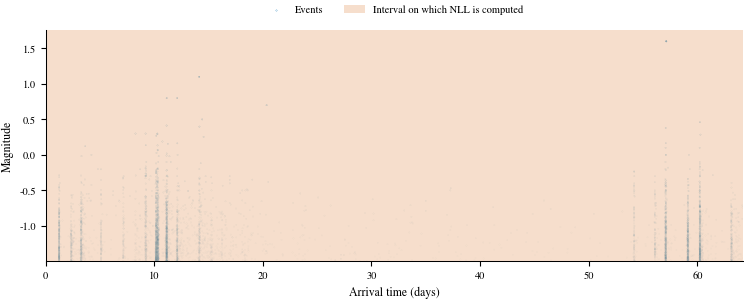

In [6]:
dataset_by_model = {name: rec['args'].dataset for name, rec in model_registry.items()}
if len(set(dataset_by_model.values())) > 1:
    print('Warning: models reference different datasets in checkpoints:')
    for name, dataset_name in dataset_by_model.items():
        print(f'  - {name}: {dataset_name}')

catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
mc = catalog_ds.metadata['mag_completeness']
print(f'Magnitude completeness: {mc}')
if  hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Primary Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

vis.visualize_sequence(full_seq, show_nll=True)


In [7]:
for name, rec in model_registry.items():
    model_i = rec['model']
    if hasattr(model_i, 'effective_branching_ratio'):
        print(f'[{name}] effective_branching_ratio:{ model_i.effective_branching_ratio(t_max=10)}')
       

[Mamba(ETAS)] effective_branching_ratio:0.8222814231773039


In [8]:
# for name, rec in model_registry.items():
#     if getattr(rec['model'], 'bg_model', None) is not None:
#         rec['model'].bg_model.stochastic_eval = False

In [9]:
catalog_ds.metadata

{'name': 'PNR_1z',
 'freq': '1D',
 'mag_roundoff_error': 0.01,
 'mag_completeness': -1.5,
 'region': '1z',
 'start_ts': Timestamp('2018-10-15 08:00:00'),
 'end_ts': Timestamp('2018-12-18 13:00:00'),
 'train_start_ts': Timestamp('2018-10-22 00:00:00'),
 'val_start_ts': Timestamp('2018-11-22 00:00:00'),
 'test_start_ts': Timestamp('2018-12-14 00:00:00')}

## 5) Batch and Multi-Model Background Diagnostics


In [10]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

SEQUENCE_IDX = globals().get('SEQUENCE_IDX', 0)
seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)
print(f'SEQUENCE_IDX: {SEQUENCE_IDX} | seq length: {len(seq)}')

SEQUENCE_IDX: 0 | seq length: 6140


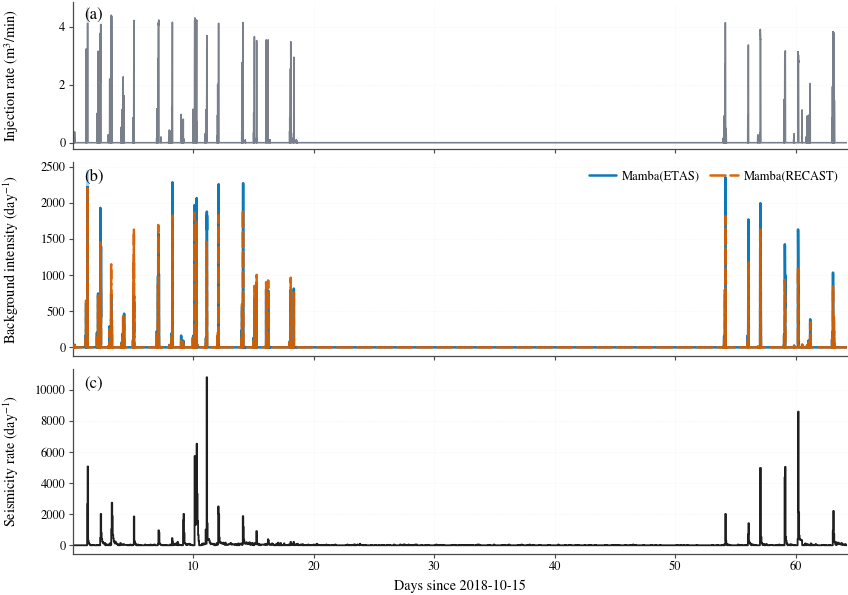

In [11]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

if diag_end <= diag_start:
    diag_end = diag_start + 1e-6

model_style_map = {
    name: get_model_style(name, idx)
    for idx, name in enumerate(model_registry.keys())
}

def _apply_diag_axis(ax, xlabel=None, ylabel=None, title=None):
    clean_axis(ax, xlabel=xlabel, ylabel=ylabel, title=title, xlim=(diag_start, diag_end))

diag_times_np = batch.time_series_times.squeeze().detach().cpu().numpy()
diag_series_np = batch.time_series.squeeze().detach().cpu().numpy()
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
time_xlabel = 'Days since ' + date_strs

bg_plot_records = []
for idx, (name, rec) in enumerate(model_registry.items()):
    model_i = rec['model']
    if getattr(model_i, 'bg_model', None) is None:
        print(f'[{name}] skipped: no bg_model.')
        continue

    f_intensity_trajectory = model_i.bg_model.intensity_trajectory(batch).reshape(-1)
    bg_plot_records.append({
        'model': name,
        'intensity': f_intensity_trajectory.detach().cpu().numpy(),
        'style': model_style_map.get(name, get_model_style(name, idx)),
    })

if not bg_plot_records:
    raise RuntimeError('No model with bg_model was found in model_registry.')

bg_model_count = len(bg_plot_records)
bg_panel_count = 1 if OVERLAY_BACKGROUND_INTENSITY else bg_model_count
if PLOT_PANEL_B_ONLY:
    fig, bg_axes = plt.subplots(
        bg_panel_count,
        1,
        figsize=(PAPER_FULL_WIDTH, max(1.45 * bg_panel_count, 2.3)),
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )
    ax_inj = None
    ax_obs = None
    bg_axes = bg_axes.ravel().tolist()
else:
    fig, axes = plt.subplots(
        bg_panel_count + 2,
        1,
        figsize=(PAPER_FULL_WIDTH, 4.0 + 1.0 * bg_panel_count),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={'height_ratios': [0.8] + [1.05] * bg_panel_count + [1.0]},
    )
    ax_inj = axes[0]
    bg_axes = list(axes[1:-1])
    ax_obs = axes[-1]
fig.patch.set_facecolor('white')

if not PLOT_PANEL_B_ONLY:
    ax_inj.plot(
        diag_times_np,
        diag_series_np,
        linewidth=0.95,
        color=INJECTION_COLOR,
        alpha=0.9,
    )
    _apply_diag_axis(ax_inj, xlabel='', ylabel=INJECTION_YLABEL)
    if SHOW_PANEL_LABELS:
        add_panel_label(ax_inj, panel_label_from_index(0))

if OVERLAY_BACKGROUND_INTENSITY:
    ax_bg = bg_axes[0]
    plot_background_intensity_lines(ax_bg, diag_times_np, bg_plot_records, model_style_map=model_style_map)
    _apply_diag_axis(ax_bg, xlabel=time_xlabel if PLOT_PANEL_B_ONLY else '', ylabel='')
    ax_bg.legend(loc='upper right', ncol=min(3, bg_model_count), **PAPER_LEGEND_KW)
    if SHOW_PANEL_LABELS and not PLOT_PANEL_B_ONLY:
        add_panel_label(ax_bg, panel_label_from_index(1))
else:
    for bg_idx, (ax_bg_i, record) in enumerate(zip(bg_axes, bg_plot_records)):
        plot_background_intensity_lines(ax_bg_i, diag_times_np, [record], model_style_map=model_style_map)
        bg_xlabel = time_xlabel if PLOT_PANEL_B_ONLY and bg_idx == bg_model_count - 1 else ''
        _apply_diag_axis(ax_bg_i, xlabel=bg_xlabel, ylabel='')
        ax_bg_i.legend(loc='upper right', **PAPER_LEGEND_KW)
        if SHOW_PANEL_LABELS and not PLOT_PANEL_B_ONLY:
            add_panel_label(ax_bg_i, panel_label_from_index(1 + bg_idx))

if not PLOT_PANEL_B_ONLY:
    vis.plot_intensity(
        seq,
        dt=1 / 24,
        ax=ax_obs,
        color=SEISMICITY_COLOR,
        T0=diag_start,
        T=diag_end,
    )
    _apply_diag_axis(ax_obs, xlabel=time_xlabel, ylabel=SEISMICITY_YLABEL)
    if SHOW_PANEL_LABELS:
        add_panel_label(ax_obs, panel_label_from_index(bg_panel_count + 1))

add_group_ylabel(fig, bg_axes, BACKGROUND_YLABEL)

save_figure_bundle(fig, COMPARE_OUTPUT_DIR / BACKGROUND_OUTPUT_NAME)
plt.show()

## 6) Single-Window Multi-Model Background Comparison


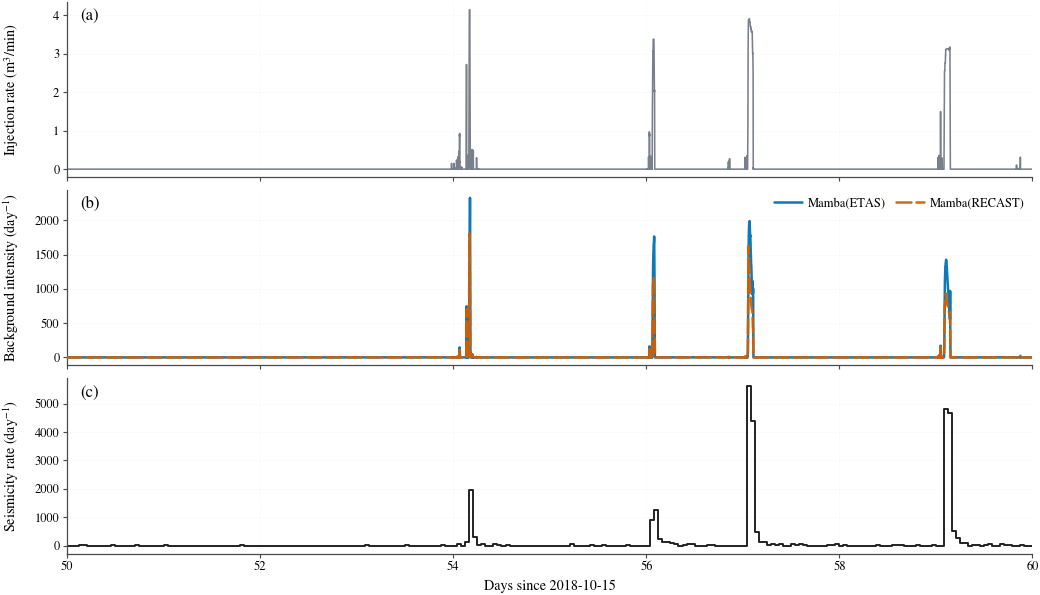

Observed events in window: 1168


,model,bg_forecast_count
0,Mamba(ETAS),194.999420
1,Mamba(RECAST),137.679749


In [12]:
past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)

mask_future = (seq.time_series_times >= window_start) & (seq.time_series_times < window_end)
future_time_series = seq.time_series[mask_future]
future_time_series_times = seq.time_series_times[mask_future]

times_all = seq.time_series_times
window_mask = (times_all >= window_start) & (times_all < window_end)
window_times = times_all[window_mask]
if window_times.numel() == 0:
    raise ValueError(f'No time_series_times points in window [{window_start}, {window_end}).')

window_times_np = window_times.detach().cpu().numpy()
future_times_np = future_time_series_times.detach().cpu().numpy()
future_series_np = future_time_series.reshape(-1).detach().cpu().numpy()

bg_count_records = []
bg_plot_records = []
for name, rec in model_registry.items():
    model_i = rec['model']
    bg_model = getattr(model_i, 'bg_model', None)
    if bg_model is None:
        print(f'[{name}] skipped in window comparison: no bg_model.')
        continue

    bg_model.cache_batch(
        time_series=seq.time_series.unsqueeze(0),
        time_series_times=seq.time_series_times.unsqueeze(0),
    )
    f_intensity = bg_model.intensity(
        ts_batch=bg_model.ts_batch_cache,
        t_query=window_times.unsqueeze(0),
    ).reshape(-1)
    f_intensity_np = f_intensity.detach().cpu().numpy()

    bg_plot_records.append({'model': name, 'intensity': f_intensity_np})
    bg_count_value = float(bg_model.forecast_count(window_start, window_end).detach().cpu().item())
    bg_count_records.append({'model': name, 'bg_forecast_count': bg_count_value})

if not bg_count_records:
    raise RuntimeError('No model with bg_model was available for window comparison.')

bg_matrix = np.vstack([row['intensity'] for row in bg_plot_records]) if bg_plot_records else np.empty((0, window_times_np.size))
inj_max = float(np.nanmax(np.abs(future_series_np))) if future_series_np.size else 0.0
bg_max = float(np.nanmax(np.abs(bg_matrix))) if bg_matrix.size else 0.0
inj_eps = max(1e-8, inj_max * 1e-3)
bg_eps = max(1e-8, bg_max * 1e-3)

activity_mask = np.zeros(window_times_np.shape, dtype=bool)
if future_times_np.size and future_series_np.size:
    inj_on_window = np.interp(window_times_np, future_times_np, future_series_np, left=0.0, right=0.0)
    activity_mask |= np.abs(inj_on_window) > inj_eps
if bg_matrix.size:
    activity_mask |= np.max(np.abs(bg_matrix), axis=0) > bg_eps

if np.any(activity_mask):
    last_active_idx = int(np.where(activity_mask)[0][-1])
    active_end = float(window_times_np[last_active_idx])
    focus_pad = max(0.15, 0.05 * (window_end - window_start))
    display_end = min(window_end, active_end + focus_pad)
else:
    display_end = window_end
display_start = window_start
if display_end <= display_start:
    display_end = display_start + max(0.5, 0.1 * (window_end - window_start))

window_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Nimbus Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8.5,
    'axes.labelsize': 8.5,
    'axes.titlesize': 9,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'lines.linewidth': 1.15,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
}

date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
time_xlabel = 'Days since ' + date_strs
window_colors = {
    'inj': INJECTION_COLOR,
    'obs': SEISMICITY_COLOR,
}

with plt.rc_context(window_rc):
    bg_model_count = len(bg_plot_records)
    bg_panel_count = 1 if OVERLAY_BACKGROUND_INTENSITY else bg_model_count
    if PLOT_PANEL_B_ONLY:
        fig, bg_axes = plt.subplots(
            bg_panel_count,
            1,
            figsize=(PAPER_FULL_WIDTH, max(1.45 * bg_panel_count, 2.3)),
            sharex=True,
            constrained_layout=True,
            squeeze=False,
        )
        ax_inj = None
        ax_obs = None
        bg_axes = bg_axes.ravel().tolist()
    else:
        fig, axes = plt.subplots(
            bg_panel_count + 2,
            1,
            figsize=(PAPER_WIDE_WIDTH, 4.0 + 1.0 * bg_panel_count),
            sharex=True,
            constrained_layout=True,
            gridspec_kw={'height_ratios': [1.0] * (bg_panel_count + 2)},
        )
        ax_inj = axes[0]
        bg_axes = list(axes[1:-1])
        ax_obs = axes[-1]
    fig.patch.set_facecolor('white')
    model_style_map = {
        row['model']: get_model_style(row['model'], idx)
        for idx, row in enumerate(bg_plot_records)
    }

    def _apply_window_axis(ax, ylabel=None, title=None, show_xlabel=False):
        clean_axis(
            ax,
            xlabel=time_xlabel if show_xlabel else '',
            ylabel=ylabel,
            title=title,
            xlim=(display_start, display_end),
        )

    if not PLOT_PANEL_B_ONLY:
        ax_inj.plot(
            future_times_np,
            future_series_np,
            color=window_colors['inj'],
            linewidth=0.95,
            alpha=0.9,
        )
        _apply_window_axis(
            ax_inj,
            ylabel=INJECTION_YLABEL
        )
        if SHOW_PANEL_LABELS:
            add_panel_label(ax_inj, panel_label_from_index(0))

    if OVERLAY_BACKGROUND_INTENSITY:
        ax_bg = bg_axes[0]
        plot_background_intensity_lines(ax_bg, window_times_np, bg_plot_records, model_style_map=model_style_map)
        _apply_window_axis(
            ax_bg,
            ylabel='',
            show_xlabel=PLOT_PANEL_B_ONLY,
        )
        ax_bg.legend(loc='upper right', ncol=min(3, bg_model_count), **PAPER_LEGEND_KW)
        if SHOW_PANEL_LABELS and not PLOT_PANEL_B_ONLY:
            add_panel_label(ax_bg, panel_label_from_index(1))
    else:
        for bg_idx, (ax_bg_i, row) in enumerate(zip(bg_axes, bg_plot_records)):
            plot_background_intensity_lines(ax_bg_i, window_times_np, [row], model_style_map=model_style_map)
            _apply_window_axis(
                ax_bg_i,
                ylabel='',
                show_xlabel=PLOT_PANEL_B_ONLY and bg_idx == bg_model_count - 1,
            )
            ax_bg_i.legend(loc='upper right', **PAPER_LEGEND_KW)
            if SHOW_PANEL_LABELS and not PLOT_PANEL_B_ONLY:
                add_panel_label(ax_bg_i, panel_label_from_index(1 + bg_idx))

    if not PLOT_PANEL_B_ONLY:
        vis.plot_intensity(
            observed_seq,
            dt=1 / 24,
            ax=ax_obs,
            color=window_colors['obs'],
            T0=window_start,
            T=window_end,
        )
        _apply_window_axis(
            ax_obs,
            ylabel=SEISMICITY_YLABEL,
            show_xlabel=True,
        )
        if SHOW_PANEL_LABELS:
            add_panel_label(ax_obs, panel_label_from_index(bg_panel_count + 1))

    add_group_ylabel(fig, bg_axes, BACKGROUND_YLABEL)

    output_base = COMPARE_OUTPUT_DIR / SINGLE_WINDOW_OUTPUT_NAME
    save_figure_bundle(fig, output_base)
    plt.show()

bg_count_df = pd.DataFrame(bg_count_records).sort_values('bg_forecast_count', ascending=False).reset_index(drop=True)
print('Observed events in window:', len(observed_seq))
bg_count_df

In [13]:
import importlib
importlib.reload(vis)

<module 'src.utils.viz_sequences' from '/home/yzzhang/pjt/chuandian_eq/src/utils/viz_sequences.py'>

  6%|▋         | 64/1000 [00:00<00:02, 385.59it/s]/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
 13%|█▎        | 128/1000 [00:00<00:06, 124.68it/s]/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
 26%|██▌       | 256/1000 [00:02<00:07, 97.63it/s] /home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
 45%|████▍     | 448/1000 [00:04<00:05, 92.10it/s]/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 3 zero inter-e

[Mamba(ETAS)] b sampling: model
[Mamba(ETAS)] Total forecasts: 1000
[Mamba(ETAS)] Forecasts containing zero inter_times: 426


/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


[Mamba(RECAST)] b sampling: model
[Mamba(RECAST)] Total forecasts: 1000
[Mamba(RECAST)] Forecasts containing zero inter_times: 46


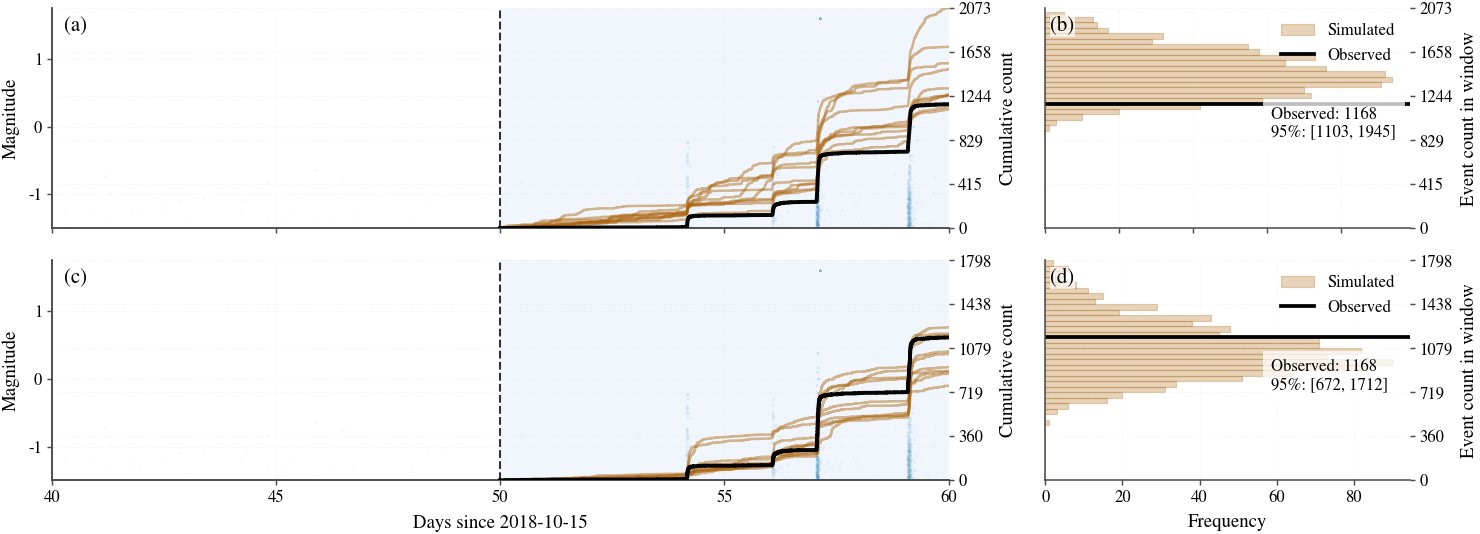

In [20]:
def supports_dynamic_b_sampling(model) -> bool:
    try:
        parameters = inspect.signature(model.sample).parameters
        if any(name in parameters for name in ('b_sampling', 'updater', 'updater_name', 'updater_cfg')):
            return True
    except Exception:
        pass
    return hasattr(model, '_normalize_b_sampling_mode')


def make_sampling_model(model, mc_value):
    if FORECAST_B_SAMPLING != 'updater':
        return model, 'model'
    if not supports_dynamic_b_sampling(model):
        print(f'{type(model).__name__} does not support updater b sampling; using model b.')
        return model, 'model'

    def updater_factory():
        return build_sampling_updater(
            model=model,
            mc=float(mc_value),
            updater_name=UPDATER_NAME,
            updater_cfg=dict(UPDATER_CFG or {}),
            device=getattr(model, 'device', DEVICE),
        )

    wrapped_model = UpdaterSamplingWrapper(
        model,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_factory=updater_factory,
    )
    return wrapped_model, FORECAST_B_SAMPLING


def move_forecasts_to_cpu(forecasts):
    return [forecast.cpu() if hasattr(forecast, 'cpu') else forecast for forecast in forecasts]


def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    sampling_model, b_sampling = make_sampling_model(model, mc)
    forecasts = sample_tpp_forecasts(
        model=sampling_model,
        past_seq=past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        bg_cache_seq=seq,
        seed=seed,
    )
    return move_forecasts_to_cpu(forecasts), b_sampling

RUN_FORECAST_SAMPLING = globals().get('RUN_FORECAST_SAMPLING', True)

if RUN_FORECAST_SAMPLING:
    past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq

    all_forecasts_by_model = {}
    zero_indices_by_model = {}

    for name, rec in model_registry.items():
        forecasts_i, b_sampling_i = generate_forecasts(
            model=rec["model"],
            past_seq=past_seq_device,
            duration=FORECAST_DURATION,
            num_samples=NUM_SAMPLES,
            samples_per_batch=SAMPLES_PER_BATCH,
            seed=SAMPLE_SEED if USE_SHARED_SAMPLE_SEED else SAMPLE_SEED + list(model_registry).index(name),
        )
        all_forecasts_by_model[name] = forecasts_i

        zero_indices_i = []
        for idx, fc in enumerate(forecasts_i):
            inter_times = torch.as_tensor(fc.inter_times).cpu()
            if (inter_times == 0).any():
                zero_indices_i.append(idx)
        zero_indices_by_model[name] = zero_indices_i

        print(f"[{name}] b sampling: {b_sampling_i}")
        print(f"[{name}] Total forecasts: {len(forecasts_i)}")
        print(f"[{name}] Forecasts containing zero inter_times: {len(zero_indices_i)}")

    all_forecasts = all_forecasts_by_model[PRIMARY_MODEL_NAME]

    date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
    fig_forecasts, axes_by_model = vis.visualize_trajectories_multi_model(
        seq,
        all_forecasts_by_model,
        save_path=None,
        figsize=(10, 1.8 * len(all_forecasts_by_model)),
        xlabel='Days since ' + date_strs,
        reset_t_nll_to_end=True,
    )
    style_existing_panel_labels(fig_forecasts)
    save_figure_bundle(fig_forecasts, COMPARE_OUTPUT_DIR / 'all_forecasts_multi_model_vertical')
    plt.show()
else:
    print('Forecast sampling skipped because RUN_FORECAST_SAMPLING=False.')
    if 'all_forecasts_by_model' in globals() and PRIMARY_MODEL_NAME in all_forecasts_by_model:
        all_forecasts = all_forecasts_by_model[PRIMARY_MODEL_NAME]
        if 'zero_indices_by_model' not in globals():
            zero_indices_by_model = {}
        print(f'Reusing existing forecasts for {PRIMARY_MODEL_NAME}: {len(all_forecasts)}')
    else:
        all_forecasts_by_model = {}
        zero_indices_by_model = {}
        all_forecasts = None
        print('No existing forecasts found; skip downstream forecast evaluation cells or run sampling first.')


## 7) RMSE, N-Test, and M-Test


Empty forecasts: 0
Forecast mag range (non-empty only): (4.05169395502264, -1.4999999040031653)
Observed mag range: (1.600000023841858, -1.4989999532699585)


[PosixPath('/home/yzzhang/pjt/chuandian_eq/notebooks/figs/bg_cmp/m_test_mamba_etas.pdf'),
 PosixPath('/home/yzzhang/pjt/chuandian_eq/notebooks/figs/bg_cmp/m_test_mamba_etas.png')]

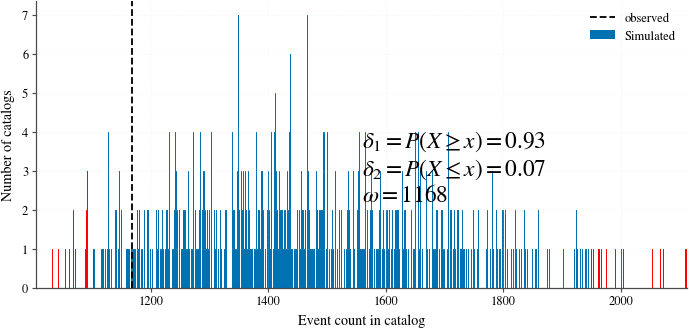

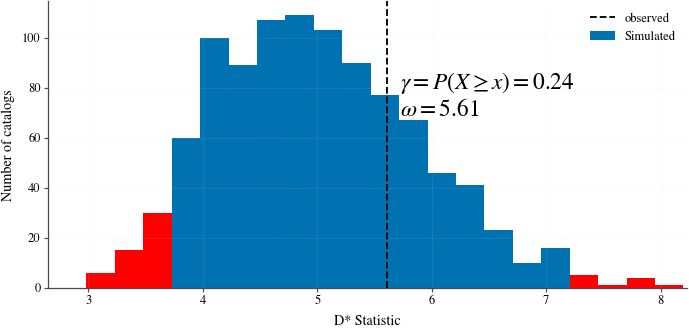

In [15]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
# rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
# print(f'RMSE: {rmse:.6f}')

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
number_test_result.plot(plot_args={'figsize': (PAPER_MEDIUM_WIDTH, 3.2), 'tight_layout': False})
fig_n = style_current_figure(title='N-Test: Observed vs Simulated Event Counts')
fig_n.patch.set_facecolor('white')
save_figure_bundle(fig_n, TEST_OUTPUT_DIR / f'n_test_{PRIMARY_MODEL_SLUG}')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
 )

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
magnitude_test_result.plot(plot_args={'figsize': (PAPER_MEDIUM_WIDTH, 3.2), 'tight_layout': False})
fig_m = style_current_figure(title='M-Test: Magnitude Distribution Comparison')
fig_m.patch.set_facecolor('white')
save_figure_bundle(fig_m, TEST_OUTPUT_DIR / f'm_test_{PRIMARY_MODEL_SLUG}')

## 8) Sliding-Window Forecast Evaluation


In [16]:
# Sliding-window settings
SLIDING_DURATION = 2
SLIDING_STEP = 2
SLIDING_QUANTILES = (2.5, 97.5)
RUN_SLIDING_WINDOW_FORECAST = False  # set to True to run the sliding window forecast, which can be time-consuming depending on settings
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'

# Cache settings: save/load sim_count_matrix and related arrays under SLIDING_OUTPUT_DIR; figures are saved separately as PNGs under COMPARE_OUTPUT_DIR.
SLIDING_LOAD_CACHE = True
SLIDING_FORCE_RECOMPUTE = False
SLIDING_CACHE_FILENAME = f"sliding_window_cache_{PRIMARY_MODEL_SLUG}.npz"


In [17]:
PLOT_COLORS = {
    'true': '#1F1F1F',
    'mean': '#0072B2',
    'pi': '#56B4E9',
    'err': '#D55E00',
    'covered': '#009E73',
    'below': '#E69F00',
    'above': '#CC79A7',
}

if RUN_SLIDING_WINDOW_FORECAST:
    sliding_result = evaluate_sliding_window_forecast_plots(
        model=model,
        seq=seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=SLIDING_OUTPUT_DIR,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=SLIDING_LOAD_CACHE,
        force_recompute_sliding=SLIDING_FORCE_RECOMPUTE,
        sliding_cache_filename=SLIDING_CACHE_FILENAME,
        save_plots=False,
        plot_colors=PLOT_COLORS,
    )

    print(f"Sliding cache path: {sliding_result.get('sliding_cache_path', 'N/A')}")
    print(f"Loaded from cache: {bool(sliding_result.get('sliding_loaded_from_cache', False))}")

    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        t_forecast_list = sliding_result['t_forecast_list']
        counts_list = sliding_result['counts_list']
        q_list = sliding_result['q_list']
        mean_list = sliding_result['mean_list']
        print(f"acceptance rate: {sliding_result['coverage']:.2%}")
        lp_nb = sliding_result.get('lp_nb')
        crps = sliding_result.get('crps')
        w95 = sliding_result.get('w95')
        lp_nb_display = 'N/A' if lp_nb is None or not np.isfinite(lp_nb) else f"{lp_nb:.4f}"
        crps_display = 'N/A' if crps is None or not np.isfinite(crps) else f"{crps:.4f}"
        print(
            f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | CRPS: {crps_display} | LP_NB: {lp_nb_display} | W95: {w95:.4f}"
        )


In [18]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(PAPER_MEDIUM_WIDTH, 2.8), constrained_layout=True)
    fig.patch.set_facecolor('white')
    latent_style = get_model_style(PRIMARY_MODEL_NAME, 0)
    latent_color = latent_style.get('color', MODEL_PALETTE[0])
    ax.plot(
        x,
        y,
        color=latent_color,
        linewidth=1.35,
        label=f'Latent mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.20,
        color=latent_color,
        label='±2 std. dev.',
    )
    clean_axis(
        ax,
        xlabel='Normalized time',
        ylabel='Latent value',
        title='Latent background process posterior',
    )
    ax.legend(loc='best', **PAPER_LEGEND_KW)
    save_figure_bundle(
        fig,
        LATENT_OUTPUT_DIR / f'latent_background_posterior_{PRIMARY_MODEL_SLUG}',
    )
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.
